In [58]:
!pip install keras-tuner
!pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ashek\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ----------------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ashek\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras_tuner as kt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [60]:
df = pd.read_csv("clean_waste_dataset.csv")

print(df.head())

  ticket_date  net_weight_kg  day_of_week  is_weekend         lag_1  \
0  2012-01-14   21837.142857            5           1  21281.428571   
1  2012-01-15   20578.571429            6           1  21837.142857   
2  2012-01-16   20524.285714            0           0  20578.571429   
3  2012-01-17   20461.428571            1           0  20524.285714   
4  2012-01-18   21251.428571            2           0  20461.428571   

          lag_7  rolling_mean_7  rolling_std_7  
0  18798.571429    20280.612245    1565.040883  
1  19275.714286    20466.734694    1501.809275  
2  18984.285714    20686.734694    1353.972164  
3  18142.857143    21017.959184     796.965699  
4  20162.857143    21173.469388     702.964015  


In [61]:
# 🔥 weekend signal (important fix)
df["weekend_signal"] = df["is_weekend"] * df["rolling_mean_7"]

In [62]:
features = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "is_weekend",
    "weekend_signal"
]

X = df[features]
y = df["net_weight_kg"]

In [63]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [64]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()

In [65]:
sample_weights = np.where(X_train["is_weekend"] == 1, 1.8, 1.0)

In [66]:
def build_model(hp):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Dense(
        units=hp.Int('units_1', 64, 256, step=64),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))

    model.add(tf.keras.layers.Dropout(
        hp.Float('dropout_1', 0.1, 0.4, step=0.1)
    ))

    model.add(tf.keras.layers.Dense(
        units=hp.Int('units_2', 32, 128, step=32),
        activation='relu'
    ))

    model.add(tf.keras.layers.Dropout(
        hp.Float('dropout_2', 0.1, 0.4, step=0.1)
    ))

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])
        ),
        loss='mse'
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    directory='tuner_dir',
    project_name='waste_prediction',
    overwrite=True  
)

tuner.search(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    sample_weight=sample_weights,
    verbose=1
)

Trial 10 Complete [00h 00m 07s]
val_loss: 0.1637272983789444

Best val_loss So Far: 0.15437182784080505
Total elapsed time: 00h 01m 22s


In [74]:
best_hp = tuner.get_best_hyperparameters(1)[0]

model = build_model(best_hp)

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    sample_weight=sample_weights,
    callbacks=[early_stop],
    verbose=1   # ✅ THIS SHOWS EPOCH TRAINING
)

Epoch 1/80


C:\Users\ashek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5488 - val_loss: 0.2370
Epoch 2/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2362 - val_loss: 0.1744
Epoch 3/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2407 - val_loss: 0.1693
Epoch 4/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2213 - val_loss: 0.1730
Epoch 5/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2225 - val_loss: 0.1659
Epoch 6/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2202 - val_loss: 0.1676
Epoch 7/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2127 - val_loss: 0.1707
Epoch 8/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2108 - val_loss: 0.1666
Epoch 9/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2025 - val_loss: 0.1668
Epoch 10/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2163 - val_loss: 0.1653
Epoch 11/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2085 - val_loss: 0.1635
Epoch 12/80
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2061 - val_loss: 0.1613


In [75]:
pred_scaled = best_model.predict(X_test_scaled)

pred = scaler_y.inverse_transform(pred_scaled)
actual = scaler_y.inverse_transform(y_test_scaled.reshape(-1,1))

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2  : {r2:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MAE : 1019.27
RMSE: 1290.54
R2  : 0.8380


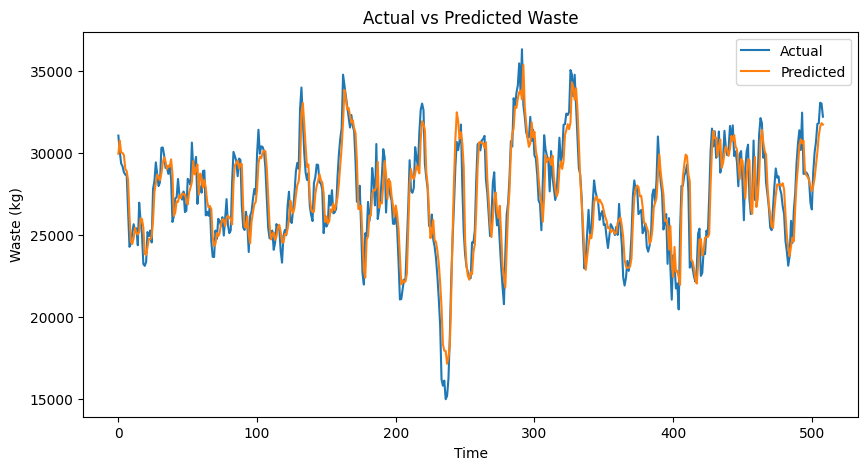

In [76]:
plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("Actual vs Predicted Waste")
plt.xlabel("Time")
plt.ylabel("Waste (kg)")
plt.legend()

plt.show()

In [78]:
import joblib

best_model.save("dl_model.h5")

joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

print("✅ FINAL TUNED MODEL SAVED")

✅ FINAL TUNED MODEL SAVED
